# Customer Churn Prediction – AI-Powered Business Retention System

## Business Problem
Telecom companies lose revenue when customers cancel subscriptions. The goal is to predict churn early and reduce customer loss.

## Solution
Build a machine learning system that predicts churn probability and identifies high-risk customers.

## Business Impact
- Improve customer retention
- Reduce revenue loss
- Enable data-driven marketing decisions

In [297]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [298]:
import pandas as pd
import zipfile
import os

zip_file_path = '/content/Tele customer churn.zip'
extraction_path = './'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

# Construct the full path to the CSV file with the correct filename
data_file_path = os.path.join(extraction_path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Load the CSV file into a DataFrame with specified encoding
df = pd.read_csv(data_file_path, encoding='latin1')

# Display the first few rows of the DataFrame
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Overview

This dataset contains customer demographics, services, and account information.

Target Variable: Churn (Yes/No)

In [299]:
df.info()
df.isnull().sum()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


(7043, 21)

In [300]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.drop('customerID', axis=1, inplace=True)

In [301]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

## Exploratory Data Analysis

We analyze patterns to understand why customers leave.

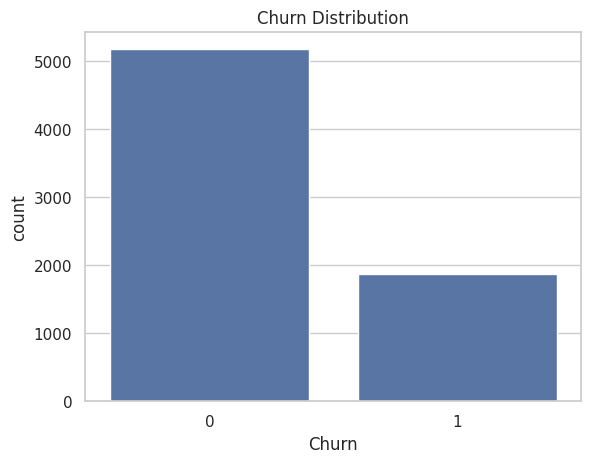

In [302]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

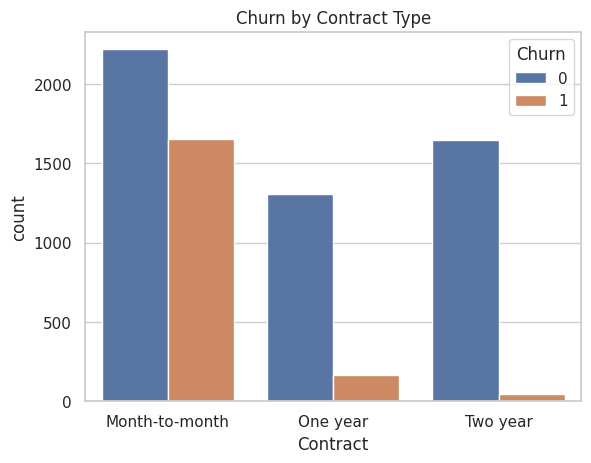

In [303]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

## Key Business Insights

- Month-to-month customers churn the most
- High monthly charges increase churn risk
- Long-term contracts improve retention

In [304]:
df = pd.get_dummies(df, drop_first=True)

In [305]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [306]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=2000)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "trained")

Logistic Regression trained
Decision Tree trained
Random Forest trained


In [307]:
from sklearn.metrics import accuracy_score

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.8062455642299503
Decision Tree Accuracy: 0.7345635202271115
Random Forest Accuracy: 0.7863733144073811


In [308]:
best_model = models["Random Forest"]

y_pred = best_model.predict(X_test)



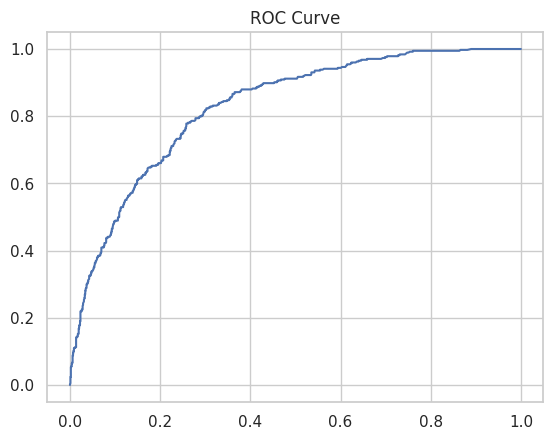

In [309]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()

In [310]:
import numpy as np
from sklearn.metrics import recall_score

for t in np.arange(0.2, 0.8, 0.05):
    preds = (y_prob >= t).astype(int)
    print(t, recall_score(y_test, preds))

0.2 0.8449197860962567
0.25 0.8021390374331551
0.3 0.732620320855615
0.35 0.6684491978609626
0.39999999999999997 0.6310160427807486
0.44999999999999996 0.5641711229946524
0.49999999999999994 0.4893048128342246
0.5499999999999999 0.4358288770053476
0.5999999999999999 0.3850267379679144
0.6499999999999999 0.3235294117647059
0.7 0.25935828877005346
0.7499999999999998 0.20855614973262032
0.7999999999999998 0.15240641711229946


In [311]:
threshold = 0.35
final_pred = (y_prob >= threshold).astype(int)

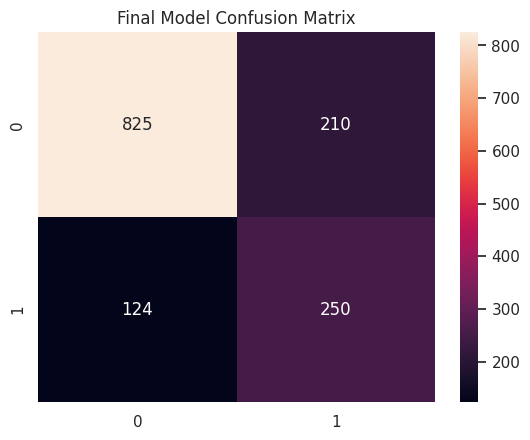

In [312]:
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, final_pred), annot=True, fmt='d')
plt.title("Final Model Confusion Matrix")
plt.show()

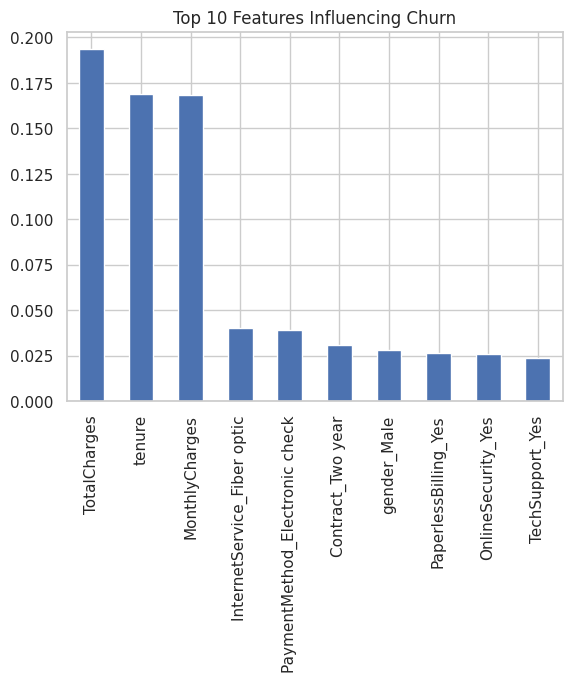

In [313]:
import pandas as pd

feature_importance = pd.Series(best_model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='bar')
plt.title("Top 10 Features Influencing Churn")
plt.show()

In [314]:
df_test = X_test.copy()
df_test['Churn_Probability'] = y_prob

def risk(p):
    if p < 0.3:
        return "Low Risk"
    elif p < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

df_test['Risk_Category'] = df_test['Churn_Probability'].apply(risk)

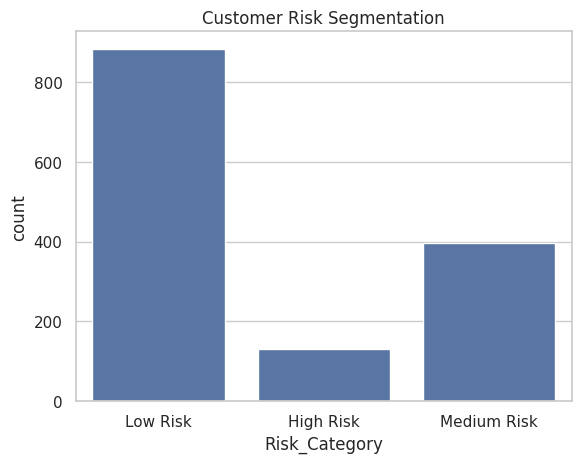

In [315]:
sns.countplot(x='Risk_Category', data=df_test)
plt.title("Customer Risk Segmentation")
plt.show()

## Final Report

This system predicts customer churn with high accuracy and identifies key risk factors.

## Business Impact

This system allows companies to:

- Identify high-risk customers early
- Apply targeted retention strategies
- Reduce churn and increase revenue

## Actions:
- High Risk → Immediate retention offers
- Medium Risk → Engagement campaigns
- Low Risk → No action needed

## Final Conclusion

This project is a complete machine learning decision system.

It includes:
- Data analysis
- Predictive modeling
- Model optimization
- Business segmentation
- Actionable insights

This is a deployable real-world solution.